# nstCollExamples\n\nCollections of spike trains.\n\nPython port of the MATLAB `nstCollExamples` helpfile (`helpfiles/nstCollExamples.m`).

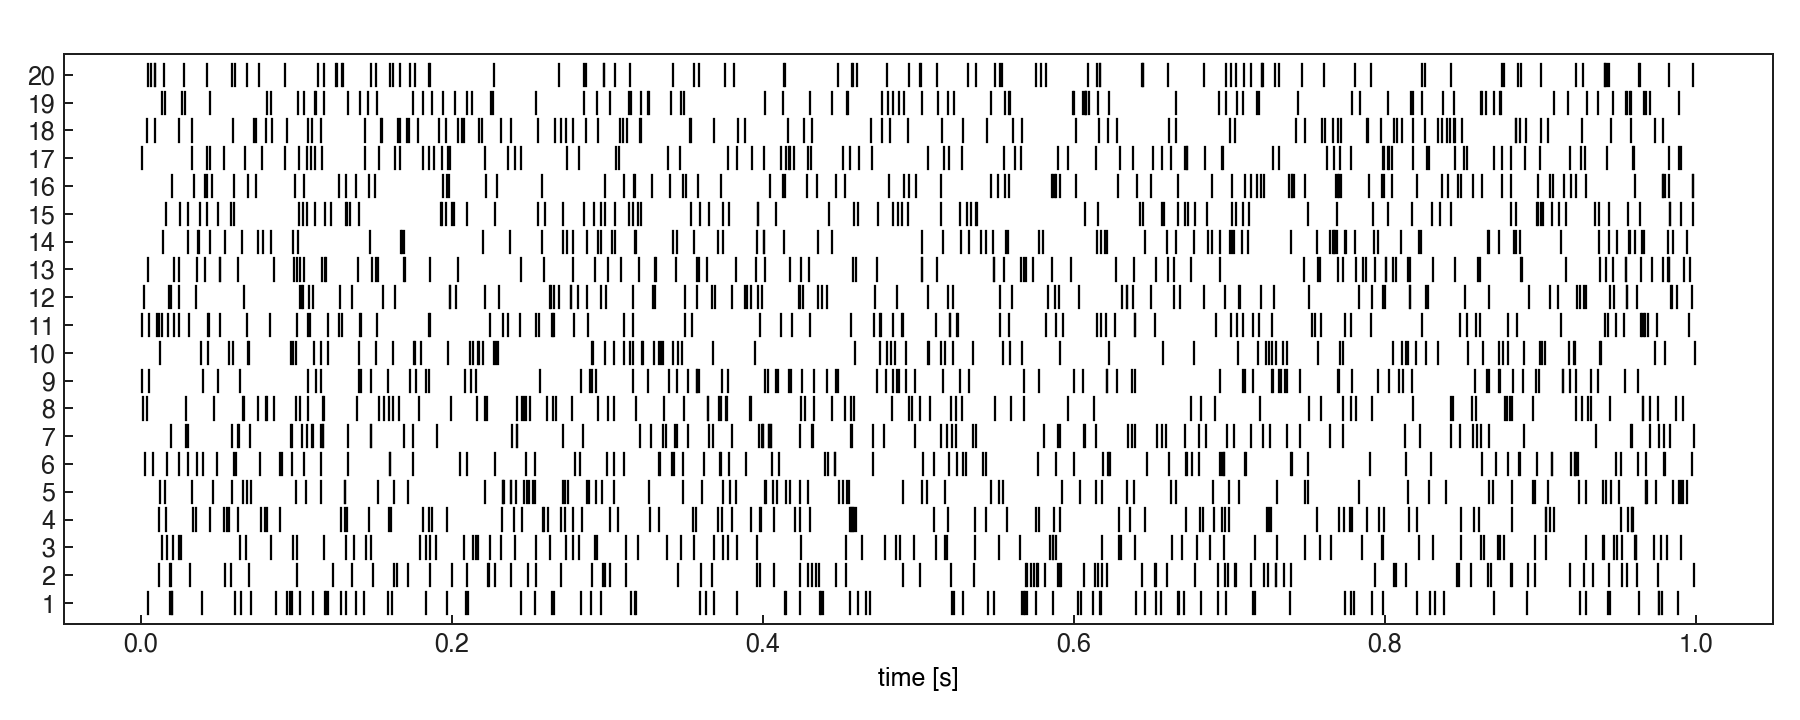

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import SignalObj, Covariate, CovColl, Events, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="nstCollExamples", output_root=OUTPUT_ROOT, expected_count=5)

def capture(label, fn):
    """For plot methods that build their own figure: discard the tracker
    placeholder, run the plot, then capture the figure it created."""
    fig = __tracker.new_figure(label)
    plt.close(fig)
    fn()
    __tracker._active_fig = plt.gcf()


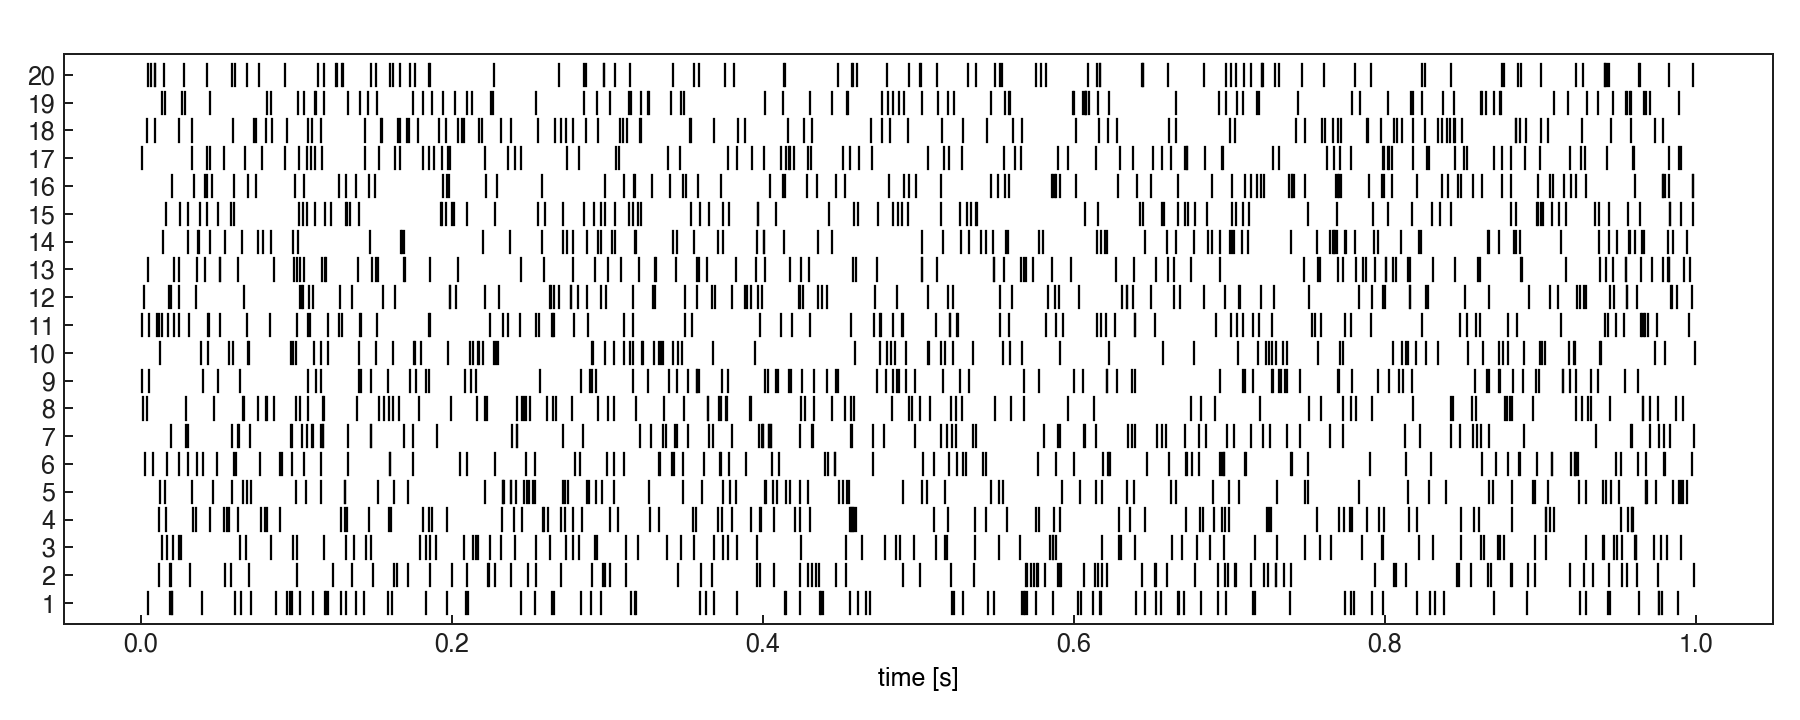

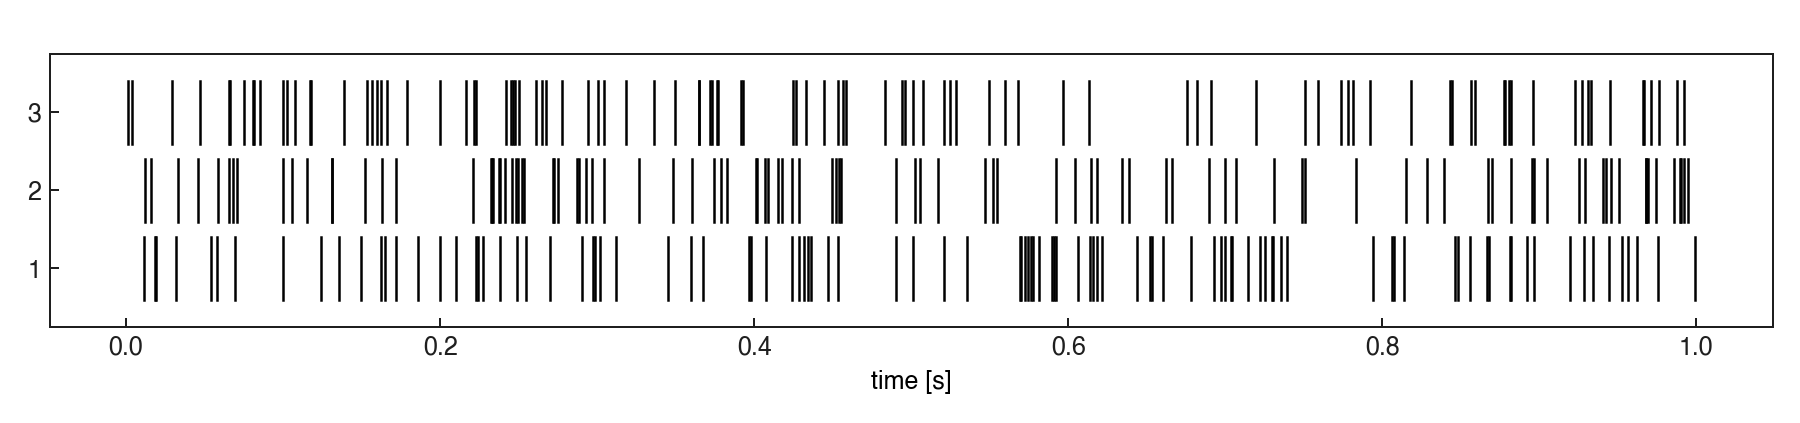

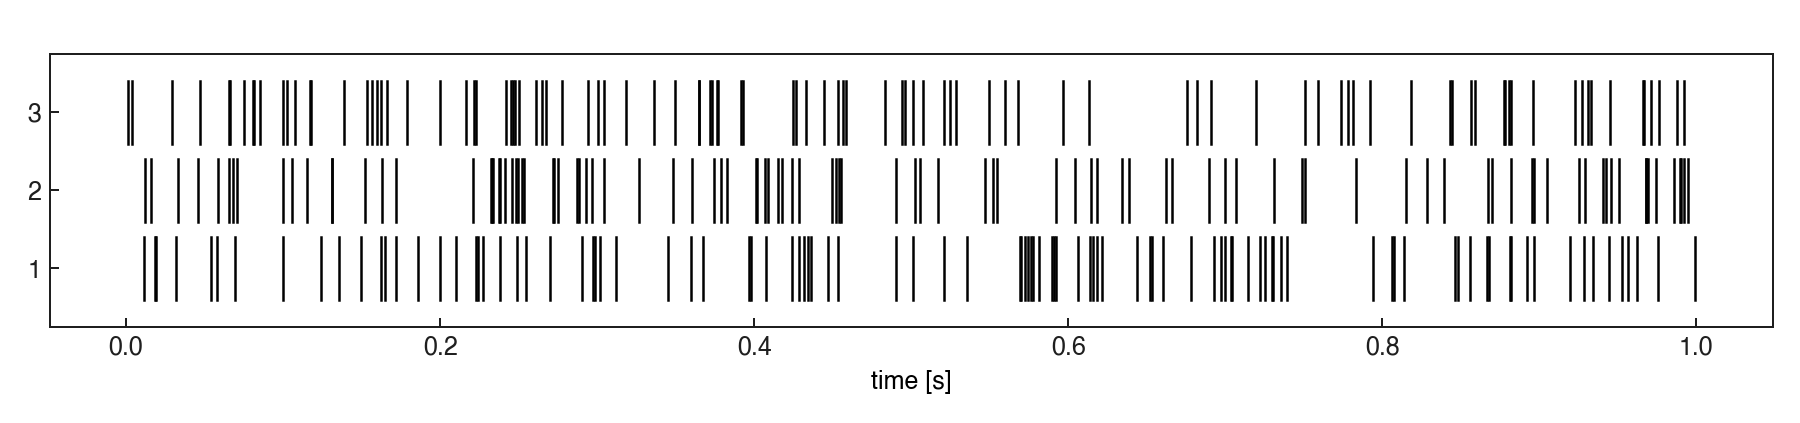

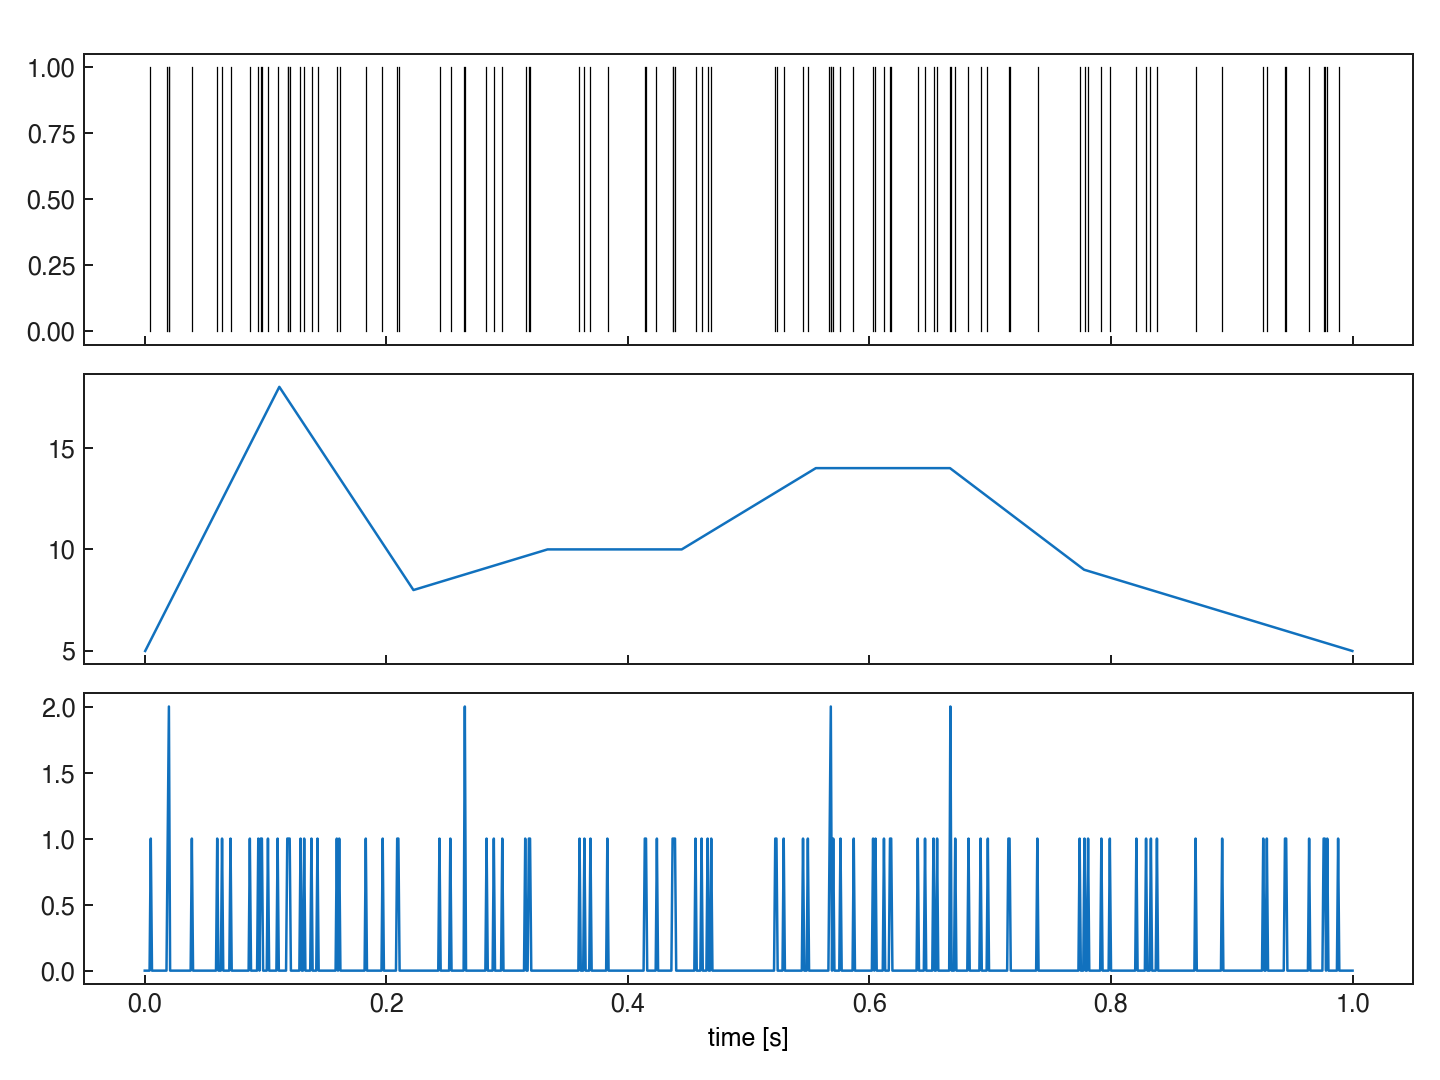

In [ ]:
trains = []
for i in range(20):
    spikeTimes = np.sort(np.random.rand(100))
    nst_i = nspikeTrain(spikeTimes, "", 10)
    nst_i.setName(f"Neuron{i+1}")
    trains.append(nst_i)
spikeColl = nstColl(trains)

def _style_full_raster(fig):
    # MATLAB renders the raster in a landscape figure where all 20 rows are
    # densely packed; ticks fill row height and y-axis shows integer
    # neuron indices only (no "Neuron N" prefix).
    fig.set_size_inches(10.0, 4.0)
    fig.suptitle("")
    for _ax in fig.axes:
        _ax.set_title("")
        _ax.set_xlabel("time [s]", fontstyle="italic")
        _ax.set_ylabel("")
        _ax.set_yticks(list(range(1, 21)))
        _ax.set_yticklabels([str(i) for i in range(1, 21)])
        # Bump tick line width on existing raster lines for MATLAB-density match.
        for _ln in _ax.get_lines():
            _ln.set_linewidth(0.9)

def _style_masked_raster(fig, labels):
    # MATLAB renders the 3-row masked raster as a compact landscape panel
    # with integer y-tick labels only (no "Neuron N" prefix) and ticks that
    # span the full row height.
    _n = max(len(labels), 1)
    _height = max(1.6, min(4.0, 0.45 * _n + 1.0))
    fig.set_size_inches(10.0, _height)
    fig.suptitle("")
    for _ax in fig.axes:
        _ax.set_title("")
        _ax.set_xlabel("time [s]", fontstyle="italic")
        _ax.set_ylabel("")
        _ax.set_yticks(list(range(1, len(labels) + 1)))
        _ax.set_yticklabels([str(i) for i in range(1, len(labels) + 1)])
        for _ln in _ax.get_lines():
            _ln.set_linewidth(1.0)

# Figure 1: raster of all 20 trains — MATLAB: landscape, Neuron{i} y-labels,
# x-axis 'time [s]', no title. (MATLAB helpfile nstCollExamples_01.png)
capture("spikeColl.plot() — all 20 trains", lambda: spikeColl.plot())
_style_full_raster(__tracker._active_fig)

# Figure 2: MATLAB publishes the same full raster a second time
# (nstCollExamples_02.png) when the setMask cell re-renders the figure
# before applying the mask. Mirror that here.
capture("spikeColl.plot() — all 20 trains (republished)", lambda: spikeColl.plot())
_style_full_raster(__tracker._active_fig)

# Figure 3: raster after setMask([1,4,7]) — only Neuron1, Neuron4, Neuron7.
# (MATLAB helpfile nstCollExamples_03.png)
spikeColl.setMask([1, 4, 7])
_mask_labels = ["Neuron1", "Neuron4", "Neuron7"]
capture("spikeColl.plot() — masked to {1,4,7}", lambda: spikeColl.plot())
_style_masked_raster(__tracker._active_fig, _mask_labels)

# Figure 4: MATLAB publishes the masked raster a second time
# (nstCollExamples_04.png) when the subsequent cell opens a new figure.
capture("spikeColl.plot() — masked to {1,4,7} (republished)", lambda: spikeColl.plot())
_style_masked_raster(__tracker._active_fig, _mask_labels)

# Figure 5: 3 vertically stacked panels for first train. (MATLAB nstCollExamples_05.png)
# MATLAB: subplot(3,1,1)=n1.plot; subplot(3,1,2)=n1.getSigRep.plot;
#         subplot(3,1,3)=n1.getSigRep(.001,0,1).plot  (delta_t = 1ms).
# nspikeTrain.getSigRep(binwidth, minTime, maxTime) takes binwidth in seconds.
n1 = spikeColl.getNST(0)
_fig5 = __tracker.new_figure("first train: raster / sigRep / fine sigRep")
# Drop the FigureTracker placeholder axis (and any suptitle) so they don't
# bleed through behind the subplot titles.
for _ax in list(_fig5.axes):
    _ax.remove()
_fig5.suptitle("")
_fig5.set_size_inches(8.0, 6.0)
_ax_a = _fig5.add_subplot(3, 1, 1)
n1.plot(handle=_ax_a)
_ax_a.set_title("")
_ax_a.set_xlabel("")
_ax_a.set_ylabel("")
_ax_a.tick_params(labelbottom=False)
_ax_b = _fig5.add_subplot(3, 1, 2, sharex=_ax_a)
n1.getSigRep().plot(handle=_ax_b)
_ax_b.set_title("")
_ax_b.set_xlabel("")
_ax_b.set_ylabel("")
_ax_b.tick_params(labelbottom=False)
_ax_c = _fig5.add_subplot(3, 1, 3, sharex=_ax_a)
n1.getSigRep(0.001, 0, 1).plot(handle=_ax_c)
_ax_c.set_title("")
_ax_c.set_xlabel("time [s]", fontstyle="italic")
_ax_c.set_ylabel("")
_fig5.subplots_adjust(hspace=0.08, left=0.1, right=0.95, top=0.95, bottom=0.1)
_fig5.suptitle("")
__tracker.finalize()
